Raw Data: [  35. 5200.   12.   40.]
Scaled Data: [0.00673077 1.         0.00230769 0.00769231]
Vector Length: 4
Number of Qubits: 2
Original: [0.2 0.5 0.3]
Padded: [0.2 0.5 0.3 0. ]
L2 Norm: 1.0000548986409987
Normalized Vector: [0.0067304  0.9999451  0.00230757 0.00769189]
Check Sum of Squares: 0.9999999999999997
Statevector([0.0067304 +0.j, 0.9999451 +0.j, 0.00230757+0.j,
             0.00769189+0.j],
            dims=(2, 2))
|00>  Amplitude: 0.006730, Probability: 0.000045
|01>  Amplitude: 0.999945, Probability: 0.999890
|10>  Amplitude: 0.002308, Probability: 0.000005
|11>  Amplitude: 0.007692, Probability: 0.000059


{'01': 1024}
Encoded Vector:
[0.0067304  0.9999451  0.00230757 0.00769189]

Statevector:
Statevector([0.0067304 +0.j, 0.9999451 +0.j, 0.00230757+0.j,
             0.00769189+0.j],
            dims=(2, 2))


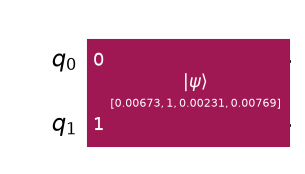

In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

x_raw = np.array([35, 5200, 12, 40], dtype=float)

print("Raw Data:", x_raw)

x_scaled = x_raw / np.max(x_raw)

print("Scaled Data:", x_scaled)

vector_length = len(x_scaled)

num_qubits = int(np.log2(vector_length))

print("Vector Length:", vector_length)
print("Number of Qubits:", num_qubits)


def pad_to_power_of_two(x):
    length = len(x)
    next_power = 2 ** int(np.ceil(np.log2(length)))

    padded = np.zeros(next_power)
    padded[:length] = x

    return padded


x_example = np.array([0.2, 0.5, 0.3])

x_padded = pad_to_power_of_two(x_example)

print("Original:", x_example)
print("Padded:", x_padded)

norm = np.linalg.norm(x_scaled)

x_normalized = x_scaled / norm

print("L2 Norm:", norm)
print("Normalized Vector:", x_normalized)
print("Check Sum of Squares:", np.sum(np.abs(x_normalized) ** 2))

state = Statevector(x_normalized)

print(state)

probabilities = np.abs(state.data) ** 2

basis_states = ["|00>", "|01>", "|10>", "|11>"]

for basis, amp, prob in zip(basis_states, state.data, probabilities):
    print(f"{basis}  Amplitude: {amp.real:.6f}, Probability: {prob:.6f}")

qc = QuantumCircuit(num_qubits)

qc.initialize(x_normalized, qc.qubits)

qc.draw("mpl")

qc_measure = QuantumCircuit(num_qubits)

qc_measure.initialize(x_normalized, qc_measure.qubits)
qc_measure.measure_all()

qc_measure.draw("mpl")

from qiskit_aer import AerSimulator
from qiskit import transpile

simulator = AerSimulator()

compiled_circuit = transpile(qc_measure, simulator)

result = simulator.run(compiled_circuit, shots=1024).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)


def amplitude_encode(x):
    x = np.array(x, dtype=float)

    # 1. Padding
    length = len(x)
    next_power = 2 ** int(np.ceil(np.log2(length)))

    padded = np.zeros(next_power)
    padded[:length] = x

    # 2. Scaling
    if np.max(np.abs(padded)) != 0:
        scaled = padded / np.max(np.abs(padded))
    else:
        scaled = padded

    # 3. Normalization
    norm = np.linalg.norm(scaled)

    if norm == 0:
        raise ValueError("입력 벡터가 모두 0입니다. Amplitude Encoding을 수행할 수 없습니다.")

    normalized = scaled / norm

    # 4. Qubit 수 계산
    num_qubits = int(np.log2(len(normalized)))

    # 5. Statevector 생성
    state = Statevector(normalized)

    # 6. Circuit 생성
    qc = QuantumCircuit(num_qubits)
    qc.initialize(normalized, qc.qubits)

    return normalized, state, qc

x_customer = [35, 5200, 12, 40]

encoded_vector, state, qc = amplitude_encode(x_customer)

print("Encoded Vector:")
print(encoded_vector)

print("\nStatevector:")
print(state)

qc.draw("mpl")


